In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

In [52]:
def mixed_walk(n_particles=100, n_steps=50, frac_det=0.5, det_step_range=(0.1, 1.0), rand_std=0.5, seed=None):
    """
    Generate a 1D walk for each particle where a fraction of steps are deterministic
    and the remaining fraction are random. Returns net displacement and path length arrays.

    Parameters:
        n_particles : int
            Number of particles.
        n_steps : int
            Total number of steps per particle.
        frac_det : float
            Fraction of steps that are deterministic (0-1).
        det_step_range : tuple
            Min and max deterministic step size.
        rand_std : float
            Standard deviation of random steps.
        seed : int or None
            Random seed for reproducibility.

    Returns:
        net : np.ndarray
            Net displacement for each particle.
        path : np.ndarray
            Total path length for each particle.
    """
    if seed is not None:
        np.random.seed(seed)

    # --- Initial positions ---
    x_init = np.random.uniform(-10, 10, n_particles)

    # --- Deterministic steps for each particle ---
    deterministic_steps = np.random.uniform(det_step_range[0], det_step_range[1], n_particles)

    # --- Number of deterministic steps ---
    n_det = int(n_steps * frac_det)

    # --- Initialize trajectories ---
    trajs = np.zeros((n_steps + 1, n_particles))
    trajs[0, :] = x_init

    # --- Generate trajectories ---
    for i in range(n_particles):
        traj = [x_init[i]]
        # deterministic steps
        for _ in range(n_det):
            traj.append(traj[-1] + deterministic_steps[i])
        # random steps
        for _ in range(n_steps - n_det):
            traj.append(traj[-1] + np.random.normal(0, rand_std))
        trajs[:, i] = traj

    # --- Compute net displacement and path ---
    net = np.abs(trajs[-1, :] - trajs[0, :])
    path = np.sum(np.abs(np.diff(trajs, axis=0)), axis=0)

    return net, path, trajs

0.25 0.325
0.5 0.605
0.75 0.83


(0.0, 100.0)

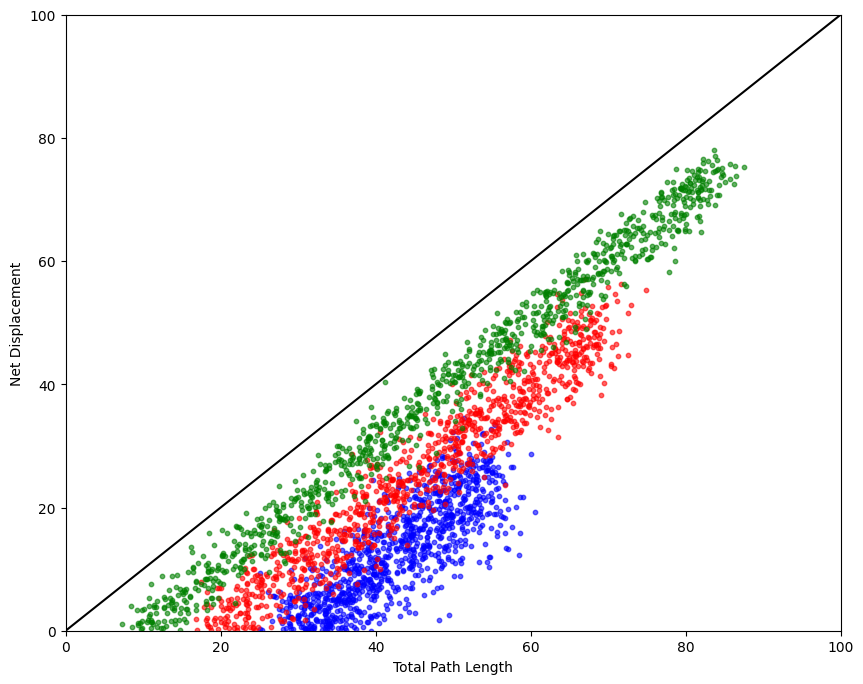

In [53]:
frac_lst = [0.25, 0.50, 0.75]
c_lst = ["b", "r", "g"]

# frac_lst = [1 / 3, 2 / 3]
# c_lst = ["r", "g"]

# frac_lst = [1 / 2]
# c_lst = ["g"]

xmax = 100
ymax = 100

plt.figure(figsize=(10, 8))
for frac, c in zip(frac_lst, c_lst):
    net, path, trajs = mixed_walk(
        n_particles=1000, n_steps=100, frac_det=frac, det_step_range=(-1, 1), rand_std=0.5, seed=0
    )
    m = np.sum(path * net) / np.sum(path**2)

    plt.scatter(path, net, alpha=0.6, c=c, s=10)
    # plt.plot([0, xmax], [0, ymax * m], c=c)

    print(frac, np.round(m, 3))

plt.plot([0, xmax], [0, ymax], c="k")

plt.xlabel("Total Path Length")
plt.ylabel("Net Displacement")

plt.xlim(0, xmax)
plt.ylim(0, ymax)

Intersection between frac_det=0.25 and frac_det=0.5: [0.477]
Intersection between frac_det=0.5 and frac_det=0.75: [0.727]


(0.0, 1.0)

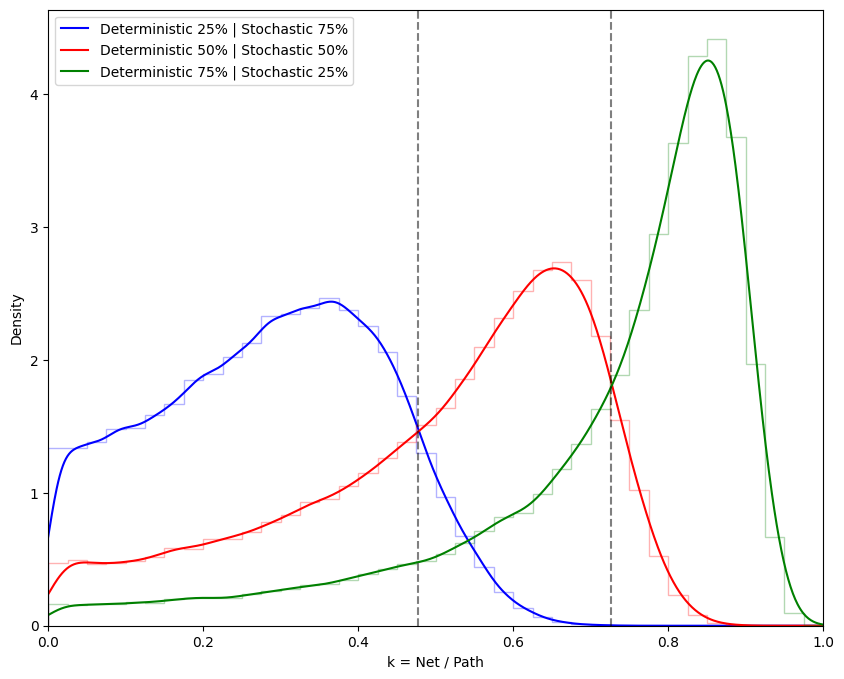

In [54]:
frac_lst = [0.25, 0.50, 0.75]
c_lst = ["b", "r", "g"]

bin_size = 0.025
bins = np.arange(0, 1 + bin_size, bin_size)
x_plot = np.linspace(0, 1, 1000)  # fine grid for smooth KDE

kdes = []

plt.figure(figsize=(10, 8))

# Compute KDEs first and plot
for frac, c in zip(frac_lst, c_lst):
    net, path, trajs = mixed_walk(
        n_particles=100000, n_steps=100, frac_det=frac, det_step_range=(-1, 1), rand_std=0.5, seed=0
    )
    k = net / path

    # Histogram (optional)
    plt.hist(k, bins, histtype="step", color=c, alpha=0.3, density=True)

    # Fit KDE
    kde = gaussian_kde(k)
    kde_vals = kde(x_plot)
    kdes.append(kde_vals)

    # Plot KDE
    # plt.plot(x_plot, kde_vals, color=c, label=str(int(frac * 100)) + "%" + " Deterministic")
    label = f"Deterministic {int(frac * 100)}% | Stochastic {int((1 - frac) * 100)}%"
    plt.plot(x_plot, kde_vals, color=c, label=label)

# Compute intersections between adjacent KDEs
for i in range(len(kdes) - 1):
    diff = kdes[i] - kdes[i + 1]
    # Find indices where the difference changes sign
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    intersections = x_plot[sign_changes]
    for x in intersections:
        plt.axvline(x, color="k", linestyle="--", alpha=0.5)
    print(
        f"Intersection between frac_det={frac_lst[i]} and frac_det={frac_lst[i + 1]}: {np.round(intersections, 3)}"
    )

plt.xlabel("k = Net / Path")
plt.ylabel("Density")
plt.legend()
plt.xlim(0, 1)

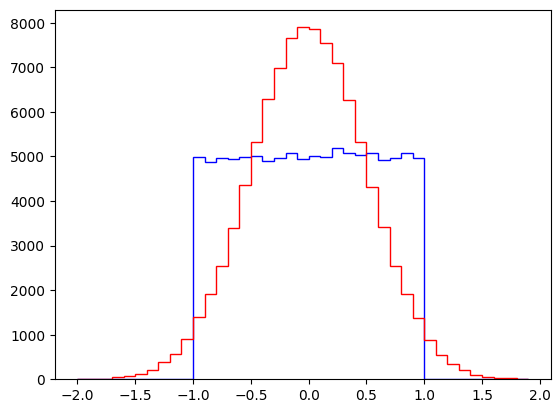

In [55]:
n_particles = 100000
det_step_range = (-1.0, 1.0)
deterministic_steps = np.random.uniform(det_step_range[0], det_step_range[1], n_particles)
bins = np.arange(-2, 2, 0.1)
plt.hist(deterministic_steps, histtype="step", bins=bins, color="b")

rand_std = 0.5
stochastic_steps = [np.random.normal(0, rand_std) for _ in range(0, n_particles)]
plt.hist(stochastic_steps, histtype="step", bins=bins, color="r")

plt.show()

In [152]:
sim = "m12i"
snap_lim = 46  # 46 for all except m12m which is 102

sim_dir = "/Users/z5114326/Documents/simulations/"

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
time_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].to_numpy()

In [ ]:
# def mixed_walk_time_dependent(
#     time_arr,
#     n_particles=100,
#     frac_det=0.5,
#     det_step_range=(0.1, 1.0),
#     rand_std=0.5,
#     det_time_scaling="linear",
#     rand_time_scaling="sqrt",
#     seed=None,
# ):
#     if seed is not None:
#         np.random.seed(seed)

#     n_steps = len(time_arr) - 1
#     dt = np.diff(time_arr)

#     # scaling arrays for det and rand
#     if det_time_scaling == "linear":
#         f_dt_det = dt
#     elif det_time_scaling == "sqrt":
#         f_dt_det = np.sqrt(dt)
#     else:
#         f_dt_det = np.ones_like(dt)

#     if rand_time_scaling == "linear":
#         f_dt_rand = dt
#     elif rand_time_scaling == "sqrt":
#         f_dt_rand = np.sqrt(dt)
#     else:
#         f_dt_rand = np.ones_like(dt)

#     # x_init = np.random.uniform(-10, 10, n_particles)
#     x_init = np.zeros(n_particles)
#     trajs = np.zeros((n_steps + 1, n_particles))
#     trajs[0, :] = x_init

#     det_steps = np.random.uniform(det_step_range[0], det_step_range[1], n_particles)

#     for i in range(n_particles):
#         traj = [x_init[i]]
#         det_indices = np.random.choice(n_steps, size=int(n_steps * frac_det), replace=False)
#         for j in range(n_steps):
#             if j in det_indices:
#                 step = det_steps[i] * f_dt_det[j]  # deterministic uses det scaling
#             else:
#                 step = np.random.normal(0, rand_std) * f_dt_rand[j]  # random uses rand scaling
#             traj.append(traj[-1] + step)
#         trajs[:, i] = traj

#     net = np.abs(trajs[-1, :] - trajs[0, :])
#     path = np.sum(np.abs(np.diff(trajs, axis=0)), axis=0)
#     return net, path, trajs


In [ ]:
def mixed_walk_time_dependent(
    time_arr,
    n_particles=100,
    frac_det=0.5,
    det_step_range=(0.1, 1.0),
    rand_std=0.5,
    det_time_scaling="linear",
    rand_time_scaling="sqrt",
    seed=None,
    # idx_min=0,
    # idx_max=21,
):
    if seed is not None:
        np.random.seed(seed)

    # x_init = np.random.uniform(-10, 10, n_particles)
    x_init = np.zeros(n_particles)
    # max_steps = len(time_arr)
    trajs = []  # list to hold arrays of different lengths

    det_steps = np.random.uniform(det_step_range[0], det_step_range[1], n_particles)

    for i in range(n_particles):
        # randomly pick a starting index for this particle
        # idx_init = np.random.choice(idx_min, 1)[0]
        t_sub = time_arr[0:]
        # t_sub = time_arr[idx_init:]
        # t_sub = time_arr[idx_min:idx_max]
        n_steps = len(t_sub) - 1
        dt = np.diff(t_sub)

        # scaling arrays for det and rand
        if det_time_scaling == "linear":
            f_dt_det = dt
        elif det_time_scaling == "sqrt":
            f_dt_det = np.sqrt(dt)
        else:
            f_dt_det = np.ones_like(dt)

        if rand_time_scaling == "linear":
            f_dt_rand = dt
        elif rand_time_scaling == "sqrt":
            f_dt_rand = np.sqrt(dt)
        else:
            f_dt_rand = np.ones_like(dt)

        traj = [x_init[i]]
        det_indices = np.random.choice(n_steps, size=int(n_steps * frac_det), replace=False)
        for j in range(n_steps):
            if j in det_indices:
                step = det_steps[i] * f_dt_det[j]  # deterministic
            else:
                step = np.random.normal(0, rand_std) * f_dt_rand[j]  # stochastic
            traj.append(traj[-1] + step)

        trajs.append(np.array(traj))

    # Compute net and path lengths for each particle
    net = np.array([np.abs(traj[-1] - traj[0]) for traj in trajs])
    path = np.array([np.sum(np.abs(np.diff(traj))) for traj in trajs])

    return net, path, trajs


0.25 0.336
0.5 0.565
0.75 0.793


(0.0, 15.0)

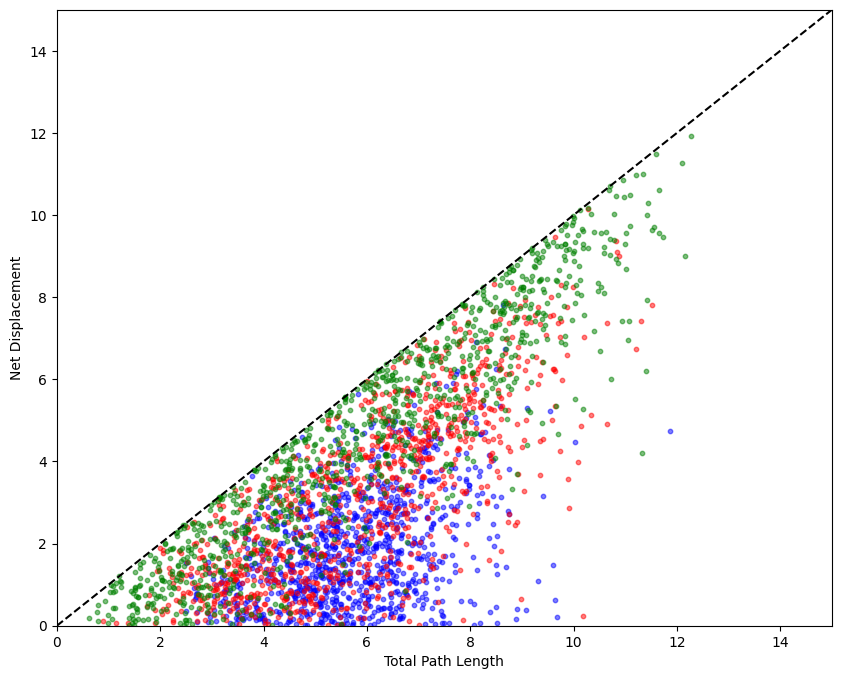

In [161]:
plt.figure(figsize=(10, 8))
for frac, c in zip([0.25, 0.5, 0.75], ["b", "r", "g"]):
    net, path, trajs = mixed_walk_time_dependent(
        time_lst, n_particles=1000, frac_det=frac, det_step_range=(-1, 1), rand_std=0.5
    )
    m = np.sum(path * net) / np.sum(path**2)
    plt.scatter(path, net, alpha=0.5, s=10, c=c)
    print(frac, np.round(m, 3))

plt.plot([0, 15], [0, 15], "k--")
plt.xlabel("Total Path Length")
plt.ylabel("Net Displacement")

plt.xlim(0, 15)
plt.ylim(0, 15)

In [114]:
# Parameters
det_step_range = (0, 1.0)  # velocity units
rand_std = 0.4  # length / sqrt(time)

# Compute Δt
dt = np.diff(time_lst)

# Deterministic steps: typical step length = mean velocity * dt
v_mean = np.mean(det_step_range)
det_steps = v_mean * dt  # array of step lengths per interval

# Stochastic steps: RMS step length = rand_std * sqrt(dt)
stoch_steps = rand_std * np.sqrt(dt)  # array of RMS step lengths per interval

print("Δt:", dt)
print("Deterministic step lengths:", det_steps)
print("Stochastic RMS step lengths:", stoch_steps)

# Optional: compare averages
print("Average deterministic step:", np.mean(det_steps))
print("Average stochastic RMS step:", np.mean(stoch_steps))


Δt: [0.09628645 0.11381529 0.13503579 0.17586995 0.20203236 0.2649678
 0.35851913 0.47492159 0.68700648 1.01239352 1.60346662 0.4438004
 0.47182319 0.52500241 0.62884793 0.67714777 0.77269042 0.86067979
 0.98765359 1.14481199 1.2759553  0.00222115 0.00221928 0.0022199
 0.00221886 0.00221865 0.0022201  0.00221823 0.00221719 0.00221947
 0.0022176 ]
Deterministic step lengths: [0.04814322 0.05690764 0.06751789 0.08793497 0.10101618 0.1324839
 0.17925956 0.23746079 0.34350324 0.50619676 0.80173331 0.2219002
 0.23591159 0.2625012  0.31442397 0.33857388 0.38634521 0.4303399
 0.4938268  0.57240599 0.63797765 0.00111057 0.00110964 0.00110995
 0.00110943 0.00110932 0.00111005 0.00110912 0.0011086  0.00110974
 0.0011088 ]
Stochastic RMS step lengths: [0.12412023 0.13494609 0.14698886 0.1677474  0.17979204 0.20590009
 0.23950587 0.27565822 0.33154341 0.40247107 0.50651225 0.26647338
 0.27475755 0.2898282  0.31719973 0.32915596 0.35161124 0.37109132
 0.39752305 0.42798355 0.45183277 0.01885162 0.0

Intersection between frac_det=0.25 and frac_det=0.5: [0.473]
Intersection between frac_det=0.5 and frac_det=0.75: [0.725]


(0.0, 1.0)

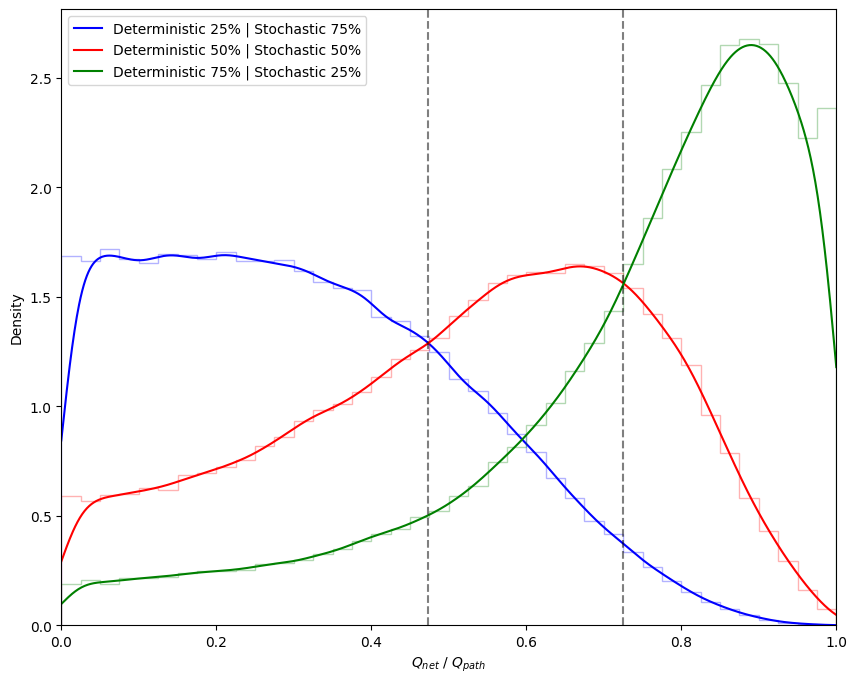

In [388]:
frac_lst = [0.25, 0.50, 0.75]
c_lst = ["b", "r", "g"]

# frac_lst = [0.25, 0.75]
# c_lst = ["r", "g"]

bin_size = 0.025
bins = np.arange(0, 1 + bin_size, bin_size)
x_plot = np.linspace(0, 1, 1000)  # fine grid for smooth KDE

kdes = []

plt.figure(figsize=(10, 8))

# Compute KDEs first and plot
for frac, c in zip(frac_lst, c_lst):
    net, path, trajs = mixed_walk_time_dependent(
        time_lst,
        n_particles=100000,
        frac_det=frac,
        det_step_range=(0, 1),
        rand_std=0.4,
        # idx_min=0,
    )
    k = net / path

    # Histogram (optional)
    plt.hist(k, bins, histtype="step", color=c, alpha=0.3, density=True)

    # Fit KDE
    kde = gaussian_kde(k)
    kde_vals = kde(x_plot)
    kdes.append(kde_vals)

    # Plot KDE
    # plt.plot(x_plot, kde_vals, color=c, label=str(int(frac * 100)) + "%" + " Deterministic")
    label = f"Deterministic {int(frac * 100)}% | Stochastic {int((1 - frac) * 100)}%"
    plt.plot(x_plot, kde_vals, color=c, label=label)

# Compute intersections between adjacent KDEs
for i in range(len(kdes) - 1):
    diff = kdes[i] - kdes[i + 1]
    # Find indices where the difference changes sign
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    intersections = x_plot[sign_changes]
    for x in intersections:
        plt.axvline(x, color="k", linestyle="--", alpha=0.5)
    print(
        f"Intersection between frac_det={frac_lst[i]} and frac_det={frac_lst[i + 1]}: {np.round(intersections, 3)}"
    )

plt.xlabel(r"$Q_{net}$ / $Q_{path}$")
plt.ylabel("Density")
plt.legend()
plt.xlim(0, 1)

# plt.yscale("log")

In [340]:
np.random.choice(2, 1)[0]

1

In [298]:
time_lst[19:]

array([11.35578917, 12.50060116, 13.77655646, 13.7787776 , 13.78099688,
       13.78321678, 13.78543564, 13.78765428, 13.78987438, 13.79209261,
       13.79430981, 13.79652928, 13.79874688])

In [ ]:
frac_lst = [0.25, 0.75]
c_lst = ["r", "g"]

bin_size = 0.025
bins = np.arange(0, 1 + bin_size, bin_size)
x_plot = np.linspace(0, 1, 1000)  # fine grid for smooth KDE

int_lst = []
for j in range(22):
    print(j)
    idx_min = j
    idx_max = j + 10

    kdes = []

    # Compute KDEs first and plot
    for frac, c in zip(frac_lst, c_lst):
        net, path, trajs = mixed_walk_time_dependent(
            time_lst,
            n_particles=100000,
            frac_det=frac,
            det_step_range=(0, 1),
            rand_std=0.4,
            idx_min=idx_min,
            idx_max=idx_max,
        )
        k = net / path

        # Fit KDE
        kde = gaussian_kde(k)
        kde_vals = kde(x_plot)
        kdes.append(kde_vals)

        # Plot KDE
        # plt.plot(x_plot, kde_vals, color=c, label=str(int(frac * 100)) + "%" + " Deterministic")
        label = f"Deterministic {int(frac * 100)}% | Stochastic {int((1 - frac) * 100)}%"

    # Compute intersections between adjacent KDEs
    for i in range(len(kdes) - 1):
        diff = kdes[i] - kdes[i + 1]
        # Find indices where the difference changes sign
        sign_changes = np.where(np.diff(np.sign(diff)))[0]
        intersections = x_plot[sign_changes]

        int_lst.append(intersections[0])


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21


In [381]:
int_lst

[0.5655655655655656,
 0.5855855855855856,
 0.6246246246246246,
 0.6066066066066066,
 0.5965965965965966,
 0.5965965965965966,
 0.5945945945945946,
 0.5965965965965966,
 0.5975975975975976,
 0.6036036036036035,
 0.6006006006006006,
 0.5875875875875876,
 0.5945945945945946,
 0.6066066066066066,
 0.6186186186186187,
 0.6406406406406406,
 0.6796796796796797,
 0.7377377377377378,
 0.914914914914915,
 0.9209209209209209,
 0.8948948948948949,
 0.5955955955955956]

In [398]:
np.mean(np.diff(time_lst[-11:])), np.mean(np.diff(time_lst[:]))

(0.0022190426999999955, 0.4172554252903226)